In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score

In [3]:
data = pd.read_csv('../data/scidcc/SciDCC.csv')
data['text'] = data['Body'].fillna(data['Summary'])
#data.head()

In [4]:
train, valid_test = train_test_split(data, test_size=0.2, random_state=16)
valid, test = train_test_split(valid_test, test_size=0.5, random_state=16)

print(f"Train size: {len(train)} ({len(train)/len(data)*100:.1f}%)")
print(f"Val size: {len(valid)} ({len(valid)/len(data)*100:.1f}%)")
print(f"Test size: {len(test)} ({len(test)/len(data)*100:.1f}%)")

Train size: 9231 (80.0%)
Val size: 1154 (10.0%)
Test size: 1154 (10.0%)


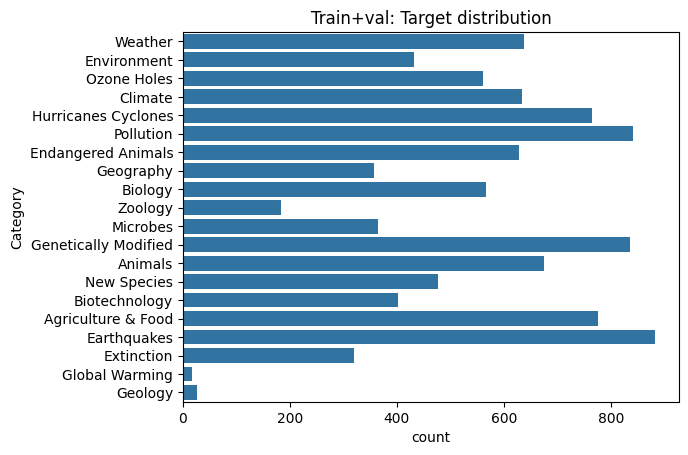

In [5]:
train_val = pd.concat([train, valid])
sns.countplot(train_val['Category']);
plt.title('Train+val: Target distribution');

In [6]:
# Convert a collection of raw documents to a matrix of TF-IDF features

text_transformer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), lowercase=True, max_features=150000) 

In [7]:
%%time
X_train_text = text_transformer.fit_transform(train_val['text'])
X_test_text = text_transformer.transform(test['text'])

X_train_text.shape, X_test_text.shape

CPU times: user 11.5 s, sys: 393 ms, total: 11.9 s
Wall time: 11.9 s


((10385, 150000), (1154, 150000))

In [ ]:
'''Logistic Regression (logit, MaxEnt) classifier
- implements regularised logistic regression
- solver ‘lbfgs’ supports only L2 regularisation by default
- C = inverse of regularisation strength (smaller values specify stronger regularisation) '''

logit = LogisticRegression(C=5e1, solver='lbfgs', multi_class='multinomial', random_state=17, n_jobs=4)


# Class-wise stratified k-fold cross-validator (provides train/test indices to split data into train/test sets)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

In [ ]:
cv_results = cross_val_score(logit, X_train_text, train_val['Category'], cv=skf, scoring='f1_macro')
cv_results, cv_results.mean()

(array([0.50727691, 0.50768335, 0.50215001, 0.50513895, 0.4895689 ]),
 np.float64(0.5023636226475707))

In [11]:
%%time
logit.fit(X_train_text, train_val['Category'])

CPU times: user 130 ms, sys: 61.4 ms, total: 192 ms
Wall time: 51.9 s


,penalty,'l2'
,dual,False
,tol,0.0001
,C,50.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,17
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [ ]:
# Get Eli report

import eli5

eli_html = eli5.show_weights(
    estimator=logit,
    feature_names=list(text_transformer.get_feature_names_out()),
    top=(50, 5)
)

eli_html

In [15]:
with open("eli5_report.html", "w") as f:
    f.write(eli_html.data)

In [ ]:
test_preds = logit.predict(X_test_text)
print(test_preds[:2])

['Biology' 'Earthquakes']


In [18]:
pd.DataFrame(test_preds, columns=['label']).head()

,label
0,Biology
1,Earthquakes
2,Extinction
3,Earthquakes
4,Biotechnology


In [19]:
pd.DataFrame(test_preds, columns=['label']).to_csv('logit_tf_idf.csv')
                                                  #index_label='id')

In [51]:
test.head()

,Date,Link,Title,Summary,Body,Category,Year
3576,"January 27, 2021",https://www.sciencedaily.com/releases/2021/01/...,New study identifies bird species that could s...,Birds play an underrecognized role in spreadin...,A new study published in the journal Lead auth...,Climate,2021
4573,"November 3, 2020",https://www.sciencedaily.com/releases/2020/11/...,Increasing the efficiency of organic solar cells,Organic solar cells are cheaper to produce and...,The sun can supply radiation energy of around ...,Environment,2020
5697,"September 13, 2016",https://www.sciencedaily.com/releases/2016/09/...,"After a strong El Nino winter, NASA model sees...","Not too hot, not too cold -- instead, water te...",Last winter saw an extremely strong El Niño ev...,Weather,2016
249,"February 25, 2013",https://www.sciencedaily.com/releases/2013/02/...,Clues to climate cycles dug from South Pole sn...,Particles from the upper atmosphere trapped in...,Anomalies in oxygen found in sulfate particles...,Ozone Holes,2013
10206,"July 9, 2020",https://www.sciencedaily.com/releases/2020/07/...,Safer CRISPR gene editing with fewer off-targe...,The CRISPR system is a powerful tool for the t...,The CRISPR system employs an enzyme called Cas...,Biotechnology,2020


In [20]:
test_labels = test["Category"].values.tolist()
print(test_labels[:2])

['Biology', 'Earthquakes']


In [21]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [22]:
accuracy = accuracy_score(test_labels, test_preds)
accuracy

0.6152512998266898

In [23]:
precision = precision_score(test_labels, test_preds, average="weighted", zero_division=np.nan)
recall = recall_score(test_labels, test_preds, average="weighted")
f1score = f1_score(test_labels, test_preds, average="macro")

print(f"Precision = {precision}")
print(f"Recall = {recall}")
print(f"F1 Score = {f1score}")

Precision = 0.6038292208007067
Recall = 0.6152512998266898
F1 Score = 0.49569345345265664


In [24]:
conf_matrix = confusion_matrix(test_labels, test_preds)
conf_matrix

array([[ 55,   3,   0,   0,   2,   0,   1,   2,   0,   3,   0,   0,   0,
          0,   1,   1,   0,   0,   0,   1],
       [  3,  48,   1,   2,   3,   0,  12,   1,   3,   2,   1,   0,   0,
          0,   1,   2,   0,   2,   0,   2],
       [  6,   5,   9,  15,   1,   0,   1,   4,   0,   2,   0,   0,   0,
          0,   9,   0,   1,   0,   0,   0],
       [  1,   0,  14,  27,   0,   0,   0,   0,   0,  10,   0,   0,   0,
          0,   5,   0,   0,   1,   0,   0],
       [  6,   1,   1,   0,  22,   1,  10,   3,   0,   0,   6,   0,   0,
          2,   0,   1,   1,   3,  10,   0],
       [  0,   0,   0,   0,   1, 100,   0,   0,   0,   0,   0,   0,   0,
          1,   0,   0,   0,   0,   1,   0],
       [  2,  14,   0,   0,   0,   0,  41,   0,   2,   2,   5,   0,   0,
          0,   0,   3,   0,   1,   1,   1],
       [  7,   2,   0,   0,   1,   0,   4,  17,   0,   1,   2,   0,   0,
          0,   2,   1,   0,   7,   1,   1],
       [  2,   4,   1,   0,   4,   0,   7,   0,  12,   0,   0,  

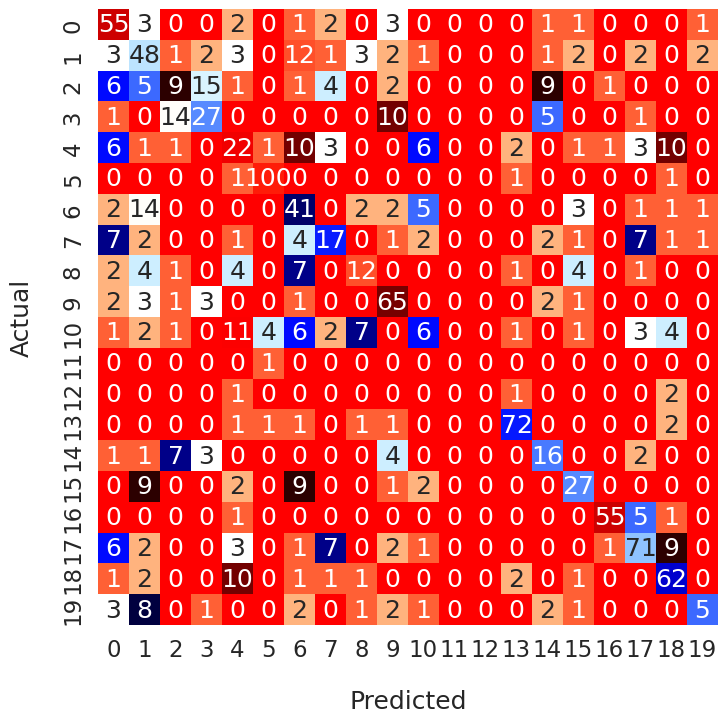

In [25]:
plt.figure(figsize=(8,8))
sns.set(font_scale = 1.5)
 
ax = sns.heatmap(
    conf_matrix, # confusion matrix 2D array 
    annot=True, # show numbers in the cells
    fmt='d', # show numbers as integers
    cbar=False, # don't show the color bar
    cmap='flag', # customize color map
    vmax=175 # to get better color contrast
)
 
ax.set_xlabel("Predicted", labelpad=20)
ax.set_ylabel("Actual", labelpad=20)
plt.show()


In [27]:
y_true = test['Category']
y_pred = logit.predict(X_test_text)

labels = np.unique(y_true)

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)



In [29]:
# convert matrix to long format
errors = []

for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j:  # only wrong predictions
            count = cm[i, j]
            if count > 0:
                errors.append((true_label, pred_label, count))

error_df = pd.DataFrame(errors, columns=["True", "Predicted", "Count"])

top_errors = error_df.sort_values("Count", ascending=False).head(20)
print(top_errors)

                   True             Predicted  Count
23              Biology         Biotechnology     15
31        Biotechnology               Biology     14
51   Endangered Animals               Animals     14
12              Animals    Endangered Animals     12
88            Geography               Climate     11
39              Climate    Endangered Animals     10
46              Climate               Weather     10
32        Biotechnology  Genetically Modified     10
132             Weather               Climate     10
115         New Species    Endangered Animals      9
113         New Species               Animals      9
129           Pollution               Weather      9
28              Biology              Microbes      9
139             Zoology               Animals      8
74           Extinction    Endangered Animals      7
59          Environment    Agriculture & Food      7
67          Environment             Pollution      7
109            Microbes               Biology 

In [36]:
error_df.to_csv("tfidf-errors.csv")

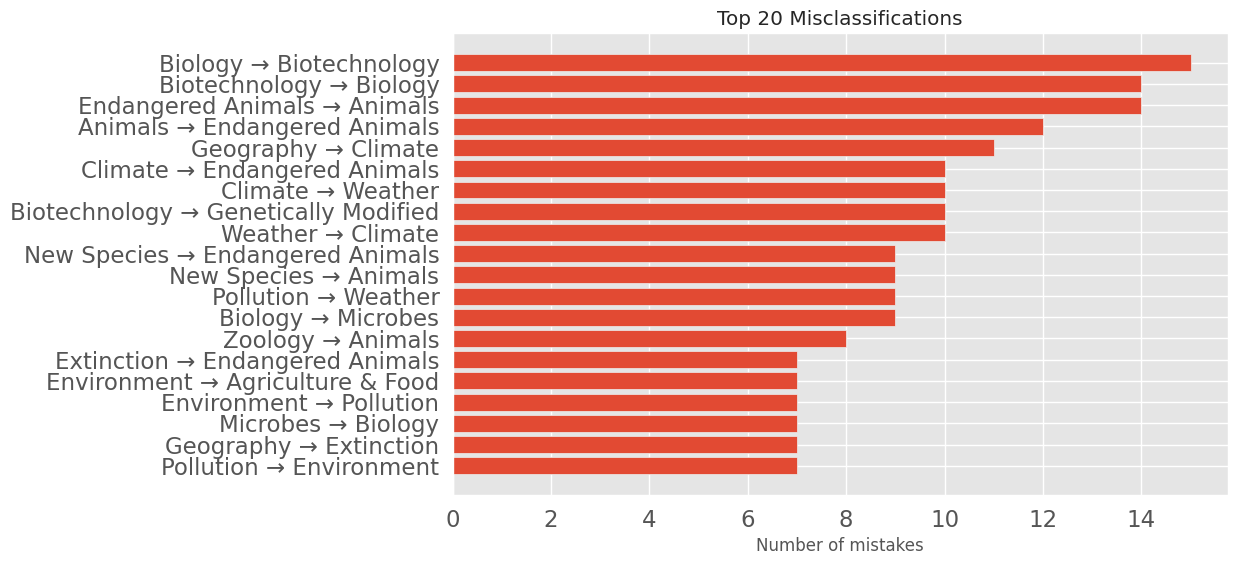

In [43]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.figure(figsize=(10, 6))
plt.barh(
    top_errors["True"] + " → " + top_errors["Predicted"],
    top_errors["Count"]
)
plt.xlabel("Number of mistakes")
plt.title("Top 20 Misclassifications")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
def plot_top_errors(top_errors, title):
    plt.figure(figsize=(10, 6))
    
    plt.barh(
        top_errors["True"] + " → " + top_errors["Predicted"],
        top_errors["Count"]
    )
    
    plt.title(title, fontsize=14)
    plt.xlabel("Number of Misclassifications")
    
    # integer ticks
    max_val = int(top_errors["Count"].max())
    plt.xticks(range(0, max_val + 1, max(1, max_val // 10)))
    
    plt.grid(True, axis="x", linestyle="--", alpha=0.5)
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

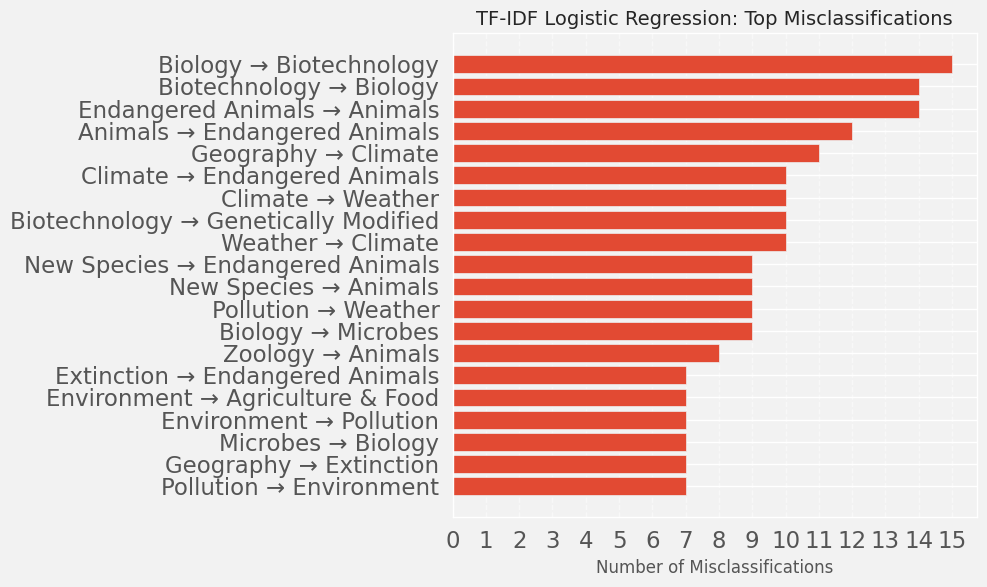

In [42]:
plot_top_errors(top_errors, "TF-IDF Logistic Regression: Top Misclassifications")

In [31]:
# most confused TRUE cases

error_df.groupby("True")["Count"].sum().sort_values(ascending=False).head(10)

True
Climate               45
Biology               44
Geography             43
Animals               35
Pollution             32
Biotechnology         31
Endangered Animals    31
Environment           29
Extinction            24
New Species           23
Name: Count, dtype: int64

In [32]:
# most problematic PREDICTED cases

error_df.groupby("Predicted")["Count"].sum().sort_values(ascending=False).head(10)

Predicted
Animals                 56
Endangered Animals      56
Agriculture & Food      41
Climate                 41
Weather                 31
Genetically Modified    30
Biology                 26
Pollution               25
Biotechnology           24
Microbes                22
Name: Count, dtype: int64